# Step 0 : Preprocessing the data

In [1]:
import os
import glob
import polars as pl
import pandas as pd
import numpy as np

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.font_manager import FontProperties

from scipy.ndimage import gaussian_filter1d

from multiprocessing import Pool
from traffic.core import Traffic, Flight

In [2]:
files = glob.glob('/store/fusg/VT1/trajectory_data/*.parquet')

df = pl.read_parquet(files).to_pandas()
trajs = Traffic(df)
print(f"Total preprocessed Flights: {len(trajs)}")

Total preprocessed Flights: 379409


## Filtering (Anomaly, Interpolation, ...)

In [3]:
def filter_enroute_segments(
    f: Flight,
    min_altitude: int = 19500,
    min_length: int = 72,
    max_interp_gap: int = 2):

    if f.data["typecode"].isna().any():
        return []

    f = f.phases()  # creates a column named 'phase' in the data
    numeric = ["latitude", "longitude", "track",
               "altitude", "groundspeed", "vertical_rate"]
    cols = ["timestamp", "icao24", "flight_id", "callsign", "typecode", "phase"] + numeric
    df = f.data[cols].copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.floor("s")

    df = (df
          .set_index("timestamp")
          .sort_index()
          .resample("1s")
          .asfreq())

    df["icao24"]    = df["icao24"].ffill().bfill()
    df["flight_id"] = df["flight_id"].ffill().bfill()
    df["callsign"]  = df["callsign"].ffill().bfill()

    # convert object-like numeric columns first to avoid pandas FutureWarning
    try:
        df = df.infer_objects(copy=False)
    except TypeError:
        df = df.infer_objects()

    df[numeric] = df[numeric].interpolate(
        method="linear",
        limit=max_interp_gap,
        limit_direction="both"
    )

    df = df.dropna(subset=numeric)

    df = df[df["altitude"] >= min_altitude]
    if df.empty:
        return []

    alt = df["altitude"].to_numpy()
    if len(alt) > 1:
        if np.max(np.abs(np.diff(alt))) > 75:
            return []

    en = Flight(df.reset_index(), callsign=f.flight_id)
    segments = en.split(1, "s")

    return [seg for seg in segments if len(seg.data) >= min_length]

def get_all_enroute_segments(trajs, n_processes=48):
    with Pool(n_processes) as pool:
        for result in tqdm(pool.imap_unordered(filter_enroute_segments, trajs), total=len(trajs), desc="Extracting enroute segments"):
            for seg in result:
                yield seg

t_enroute = Traffic.from_flights(get_all_enroute_segments(trajs))
print(f"Total enroute segments: {len(t_enroute)}")

Extracting enroute segments:   0%|          | 0/379409 [00:00<?, ?it/s]

Total enroute segments: 180519


In [4]:
t_enroute[0].data.columns

Index(['timestamp', 'icao24', 'flight_id', 'callsign', 'typecode', 'phase',
       'latitude', 'longitude', 'track', 'altitude', 'groundspeed',
       'vertical_rate'],
      dtype='object')

## Feature Extraction

### Typecode

In [5]:
n = 1500

# Prepare data
typecodes = []
for flight in t_enroute:
    if not flight.data.empty and 'typecode' in flight.data.columns:
        tc = flight.data['typecode'].iloc[0]
        if pd.notna(tc):
            typecodes.append(tc)

df_typecodes = pd.DataFrame({'typecode': typecodes})
counts = df_typecodes['typecode'].value_counts()
frequent_types = counts[counts > n].index.tolist()

counts = counts[counts > n].sort_values(ascending=False)
print(f"Frequent typecodes (count > {n}):", frequent_types)

Frequent typecodes (count > 1500): ['A320', 'B738', 'A319', 'A20N', 'A321', 'B38M', 'BCS3', 'A21N', 'B77W', 'E190', 'B789', 'A333', 'E195', 'A359', 'PC12', 'BCS1']


/tmp/ipykernel_1465003/2917091105.py:13: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(13, 4))


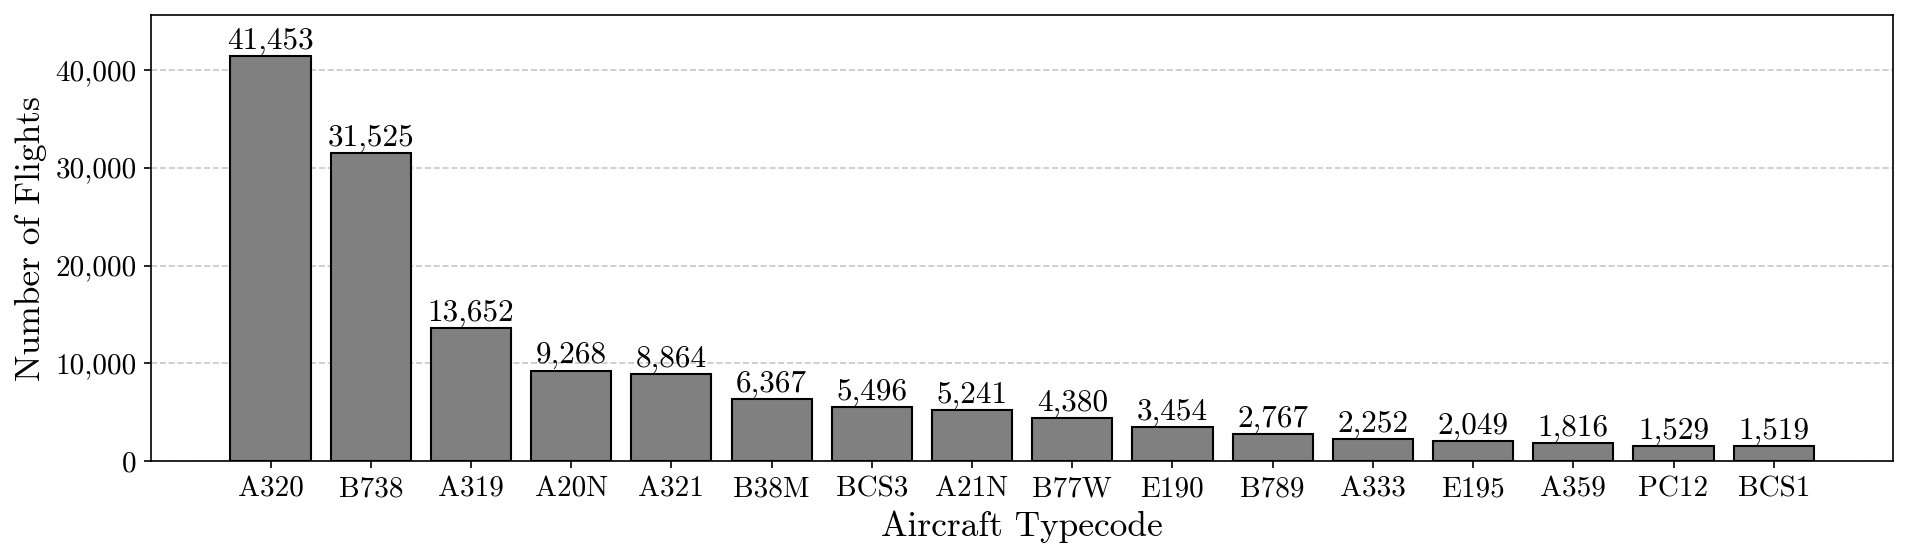

In [6]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'cmr10',
    'font.size': 16,
    'axes.labelsize': 17,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 150
})

# Create figure
fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(counts.index, counts.values, color='gray', edgecolor='black')
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 0.5),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=15)

import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add labels and title
ax.set_xlabel('Aircraft Typecode')
ax.set_ylabel('Number of Flights')
ax.set_ylim(0, counts.values.max() * 1.1)
#ax.set_title('Most Frequent Aircraft Typecodes')

plt.tight_layout()
plt.show()

In [7]:
t_encode = t_enroute
t_encode.data = t_enroute.data[t_encode.data['typecode'].isin(frequent_types)]

# Show the difference between total flights and flights with data
print(f"Total flights in t_encode object: {len(t_encode)}")
print(f"Flights that actually have data rows: {t_encode.data['flight_id'].nunique()}")
print(f"Difference (flights with no data): {len(t_encode) - t_encode.data['flight_id'].nunique()}")

# Rebuild t_encode to match reality
t_encode = Traffic(t_encode.data)
print(f"\nAfter rebuilding t_encode:")
print(f"Total flights in t_encode object: {len(t_encode)}")
print(f"Flights that actually have data rows: {t_encode.data['flight_id'].nunique()}")

Total flights in t_encode object: 180519
Flights that actually have data rows: 141661
Difference (flights with no data): 38858

After rebuilding t_encode:
Total flights in t_encode object: 141661
Flights that actually have data rows: 141661


### Add kinematic features

In [8]:
print("Raw (t_encode.data) stats:")
print(t_encode.data[['groundspeed','vertical_rate', 'track', 'altitude']].describe())

Raw (t_encode.data) stats:
        groundspeed  vertical_rate         track      altitude
count  9.868208e+07   9.868208e+07  9.868208e+07  9.868208e+07
mean   4.393153e+02   1.912311e+01  1.867704e+02  3.382472e+04
std    4.760684e+01   6.892603e+02  1.057405e+02  4.795563e+03
min    0.000000e+00  -3.264000e+04  0.000000e+00  1.950000e+04
25%    4.113720e+02  -4.682540e+01  1.160911e+02  3.200000e+04
50%    4.404529e+02   0.000000e+00  1.820008e+02  3.532500e+04
75%    4.704765e+02   5.630769e+01  2.932178e+02  3.700000e+04
max    4.706952e+03   3.264000e+04  3.598970e+02  4.500000e+04


In [9]:
df_filtered = t_encode.iterate_lazy(tqdm_kw={"disable": False}).filter("aggressive").eval(max_workers=48, desc="Filtering")

0it [00:00, ?it/s]

Filtering:   0%|          | 0/141661 [00:00<?, ?it/s]

In [10]:
print("Filtered (t_encode.data) stats:")
print(df_filtered.data[['groundspeed','vertical_rate', 'track', 'altitude']].describe())

Filtered (t_encode.data) stats:
        groundspeed  vertical_rate         track      altitude
count  9.868208e+07   9.868208e+07  9.868208e+07  9.868208e+07
mean   4.393076e+02   1.904688e+01  1.867705e+02  3.382452e+04
std    4.749176e+01   6.750806e+02  1.057376e+02  4.795724e+03
min    0.000000e+00  -2.944000e+04  0.000000e+00  1.950000e+04
25%    4.113718e+02  -3.827889e+01  1.161070e+02  3.200000e+04
50%    4.404468e+02   0.000000e+00  1.819995e+02  3.532421e+04
75%    4.704765e+02   4.403265e+01  2.932178e+02  3.700000e+04
max    3.641845e+03   3.193600e+04  3.598919e+02  4.500000e+04


In [11]:
def add_numerical_features(df):
    df = df.copy()

    df["timestamp"] = df["timestamp"].dt.tz_localize(None)
    secs = df["timestamp"].diff().dt.total_seconds().fillna(1.0)

    # extra safety protection
    secs[secs == 0] = 1.0

    # sin/cos of track
    tr_rad = np.deg2rad(df["track"])
    df["track_sin"] = np.sin(tr_rad)
    df["track_cos"] = np.cos(tr_rad)

    # turn‐rate (deg/s)
    tr_unw  = np.unwrap(tr_rad)
    turn_rate = np.diff(np.insert(tr_unw, 0, tr_unw[0])) / secs
    df["turn_rate"] = turn_rate * 180 / np.pi

    # unit conversions
    df["groundspeed"] = df["groundspeed"] * 0.514444  # kts to m/s
    df['vertical_rate'] = df['vertical_rate'] * 0.00508 # ft/min to m/s

    # acceleration (m/s^2)
    df["acceleration"] = (
        df["groundspeed"].diff().fillna(0.0) / secs
    )

    return df

df = add_numerical_features(df_filtered.data)
traff = Traffic(df)
print(f"Total flights : {len(traff)}")
print(traff.data.columns)

print("\n")
print(df[['groundspeed', 'vertical_rate','acceleration', 'turn_rate']].describe())

Total flights : 141661
Index(['timestamp', 'icao24', 'flight_id', 'callsign', 'typecode', 'phase',
       'latitude', 'longitude', 'track', 'altitude', 'groundspeed',
       'vertical_rate', 'track_sin', 'track_cos', 'turn_rate', 'acceleration'],
      dtype='object')


        groundspeed  vertical_rate  acceleration     turn_rate
count  9.868208e+07   9.868208e+07  9.868208e+07  9.868208e+07
mean   2.259991e+02   9.675817e-02 -1.292377e-04  5.472492e-04
std    2.443185e+01   3.429409e+00  6.971758e-01  1.569699e+00
min    0.000000e+00  -1.495552e+02 -1.672165e+03 -1.798166e+02
25%    2.116277e+02  -1.944568e-01 -2.345616e-02  0.000000e+00
50%    2.265852e+02   0.000000e+00  0.000000e+00  0.000000e+00
75%    2.420338e+02   2.236859e-01  2.339289e-02  0.000000e+00
max    1.873525e+03   1.622349e+02  1.672410e+03  1.797954e+02


## Statistics Extraction

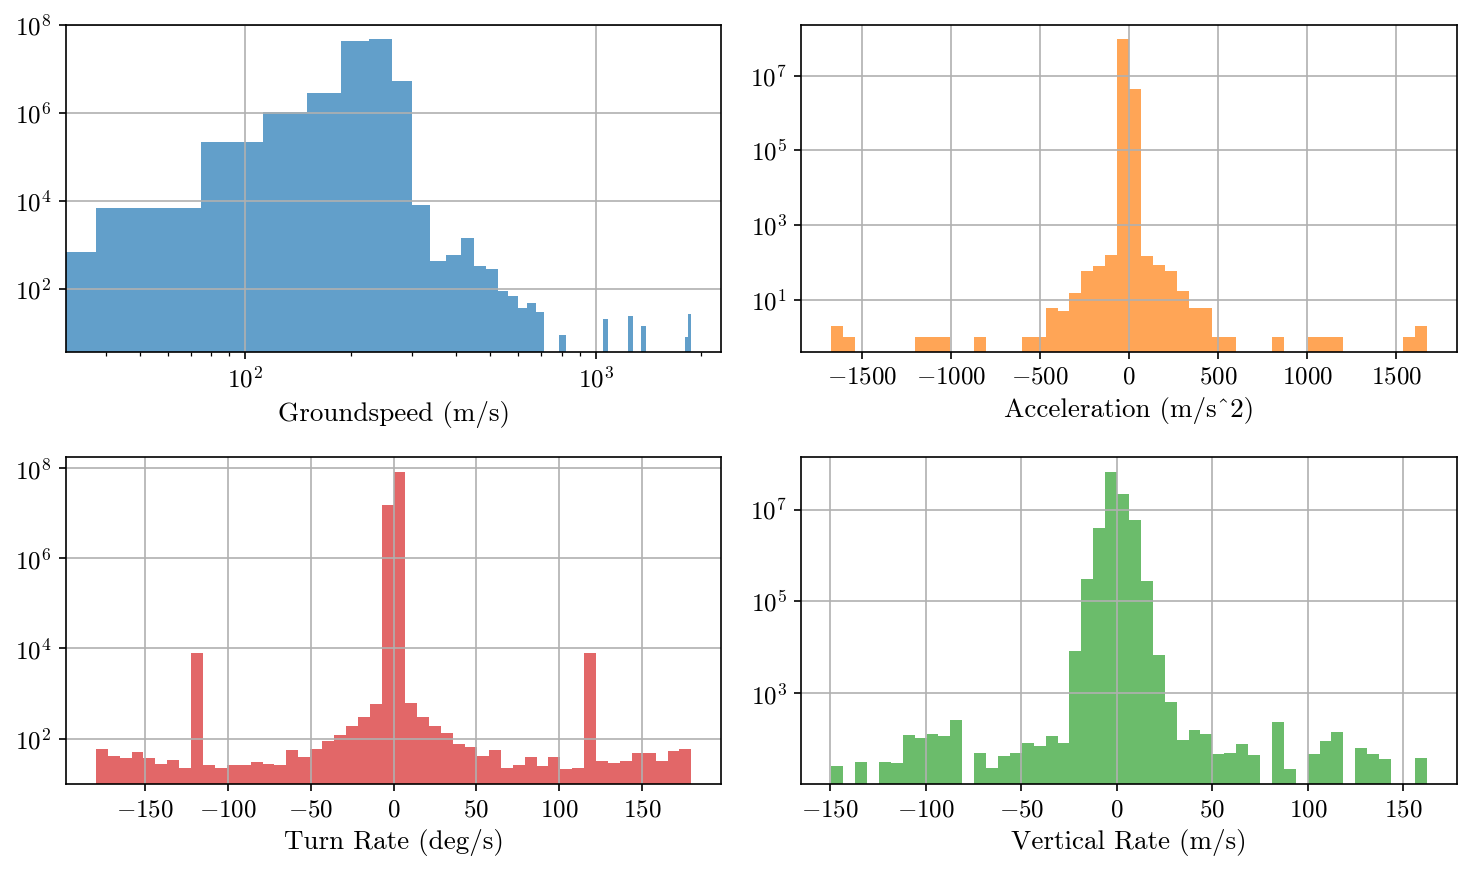

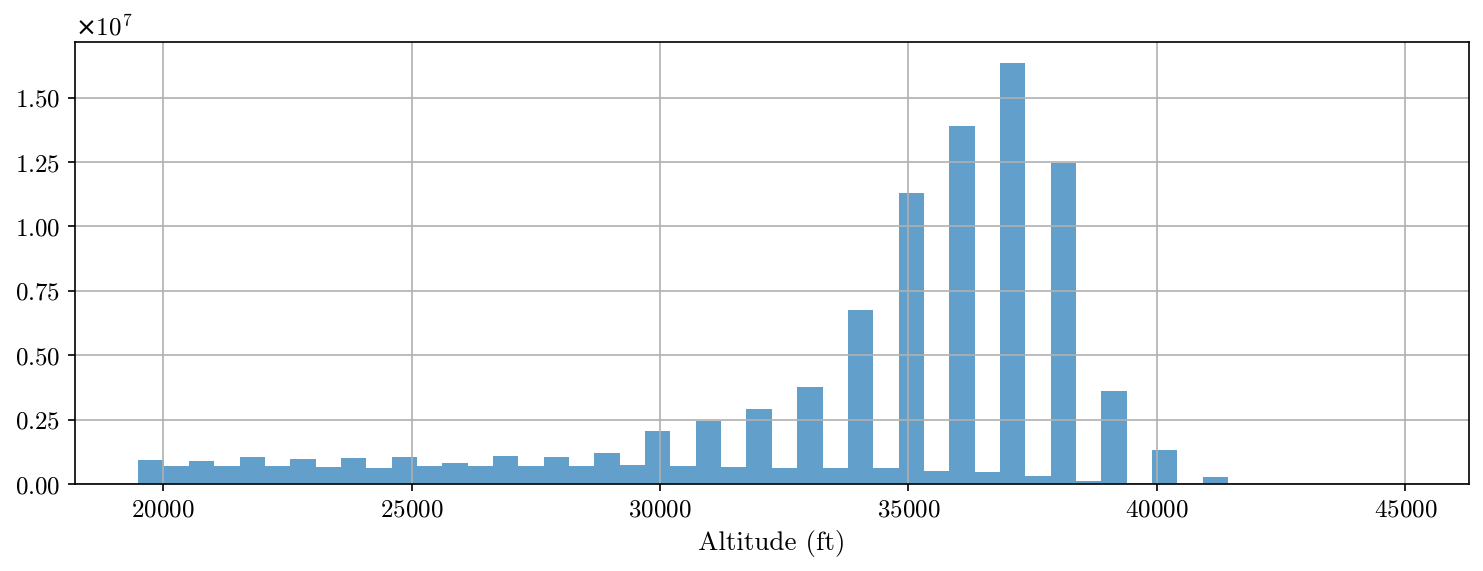

Groundspeed stats (per flight):
count    141661.000000
mean        225.375207
std          24.110065
min          21.392052
25%         210.947271
50%         225.773963
75%         240.956313
max         413.135978
Name: groundspeed, dtype: float64

Acceleration (m/s^2) stats (per flight):
count    141661.000000
mean          0.002706
std           0.047116
min          -2.039195
25%          -0.010852
50%          -0.000246
75%           0.011196
max           2.860883
Name: acceleration, dtype: float64

Turn Rate (deg/s) stats (per flight):
count    141661.000000
mean          0.000752
std           0.125219
min          -4.934211
25%          -0.010097
50%           0.000290
75%           0.010960
max           4.930720
Name: turn_rate, dtype: float64

Vertical Rate (m/s) stats (per flight):
count    141661.000000
mean          0.356337
std           3.485049
min         -98.778348
25%          -0.094144
50%           0.000814
75%           0.514040
max          30.134761
Name: ver

In [16]:
# Set cmr10 globally
plt.rcParams.update({
    'text.usetex': False,
    'axes.formatter.use_mathtext' : True,
    'font.family': 'cmr10',
    'font.size': 13,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150
})

df = traff.data

# Plot histograms for key features
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Groundspeed (airspeed)
df['groundspeed'].dropna().hist(bins=50, ax=axes[0,0], color="tab:blue", alpha=0.7)
axes[0,0].set_xlabel('Groundspeed (m/s)')
axes[0,0].set_yscale('log')
axes[0,0].set_xscale('log')
#axes[0,0].set_ylabel('Number of Data Points')

# Acceleration
df['acceleration'].dropna().hist(bins=50, ax=axes[0,1], color="tab:orange", alpha=0.7)
axes[0,1].set_xlabel('Acceleration (m/s^2)')
axes[0,1].set_yscale('log')
#axes[0,1].set_ylabel('Number of Data Points')

# Turn rate
df['turn_rate'].dropna().hist(bins=50, ax=axes[1,0], color="tab:red", alpha=0.7)
axes[1,0].set_xlabel('Turn Rate (deg/s)')
axes[1,0].set_yscale('log')
#axes[1,0].set_ylabel('Number of Data Points')

# Vertical rate
df['vertical_rate'].dropna().hist(bins=50, ax=axes[1,1],  color="tab:green", alpha=0.7)
axes[1,1].set_xlabel('Vertical Rate (m/s)')
axes[1,1].set_yscale('log')
#axes[1,1].set_ylabel('Number of Data Points')

plt.tight_layout()
plt.show()

#  altitude
fig2, ax2 = plt.subplots(figsize=(10, 4))
df['altitude'].dropna().hist(bins=50, ax=ax2, alpha=0.7)
ax2.set_xlabel('Altitude (ft)')
#ax2.set_ylabel('Number of Data Points')

plt.tight_layout()
plt.show()

# Print some stats for continuous features (per flight)
print("Groundspeed stats (per flight):")
print(df.groupby('flight_id')['groundspeed'].mean().describe())
print("\nAcceleration (m/s^2) stats (per flight):")
print(df.groupby('flight_id')['acceleration'].mean().describe())
print("\nTurn Rate (deg/s) stats (per flight):")
print(df.groupby('flight_id')['turn_rate'].mean().describe())
print("\nVertical Rate (m/s) stats (per flight):")
print(df.groupby('flight_id')['vertical_rate'].mean().describe())

## Final Save

In [13]:
path_traff = f"/store/fusg/VT2/training/traffic_data.parquet"
df.to_parquet(path_traff, index=False)

np.save(f"/store/fusg/VT2/training/frequent_typecodes.npy", frequent_types)